In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from matplotlib import pyplot as plt

In [3]:
df = pd.read_csv('data_01.csv')

#a0 download data and use it by csv file through panda

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      199 non-null    float64
 1   x2      199 non-null    float64
 2   x3      199 non-null    float64
 3   x4      199 non-null    float64
 4   x5      199 non-null    float64
 5   target  199 non-null    float64
dtypes: float64(6)
memory usage: 9.5 KB


#b) we EDA data : what is data set , what is missing in data set .what is our target..etc
 

In [5]:
df.head(5)

,x1,x2,x3,x4,x5,target
0,0.743487,1.072825,1.332911,-1.244771,0.344978,220.173943
1,0.835264,0.202184,0.966480,0.745883,-0.033773,175.873929
2,-1.103234,0.030615,-0.140385,0.727683,-2.831224,-162.270054
3,1.210186,1.685258,-0.394123,0.719024,-2.166585,165.930461
4,0.474577,0.647737,-0.451812,-0.409472,-0.051473,43.250511


c) we first seprate train data and test data into x and y 

In [6]:
x = df.drop('target',axis=1)
print(x)

           x1        x2        x3        x4        x5
0    0.743487  1.072825  1.332911 -1.244771  0.344978
1    0.835264  0.202184  0.966480  0.745883 -0.033773
2   -1.103234  0.030615 -0.140385  0.727683 -2.831224
3    1.210186  1.685258 -0.394123  0.719024 -2.166585
4    0.474577  0.647737 -0.451812 -0.409472 -0.051473
..        ...       ...       ...       ...       ...
194  0.506013 -1.546832  1.371920  0.365069  1.217062
195 -0.108058  0.008594 -0.244017  0.624930  0.397292
196 -0.331685  0.763282 -0.046545 -2.077271 -0.441957
197  3.106505  1.060556 -0.709179 -1.876106  0.161476
198 -0.628655 -0.142817 -2.219201 -2.189732  0.720388

[199 rows x 5 columns]


In [7]:
y = df['target']
print(y)

0      220.173943
1      175.873929
2     -162.270054
3      165.930461
4       43.250511
          ...    
194     48.732442
195     -0.346974
196    -30.311940
197    237.660709
198   -260.843988
Name: target, Length: 199, dtype: float64


d) train test split 80% 20% and than tain data split train and val data set where train(80-80*15%)

In [8]:
x_train_val,x_test,y_train_val,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [9]:
x_train,x_val,y_train,y_val = train_test_split(x_train_val,y_train_val,test_size=0.15,random_state=42)

In [10]:
print(x_train.shape)

(135, 5)


train data two diffrent model Linear rigerssion and desion tree and find which is best


In [11]:
linear_model = LinearRegression()
linear_model.fit(x_train,y_train)
linear_pred = linear_model.predict(x_val)

In [12]:
r2 = r2_score(y_val,linear_pred)
print("r2 score for linear regression model is:",r2)

r2 score for linear regression model is: 0.9991051178834996


class sklearn.tree.DecisionTreeRegressor(*, criterion='squared_error', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, ccp_alpha=0.0, monotonic_cst=None)

In [13]:
tree_reg= DecisionTreeRegressor (criterion='squared_error', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, ccp_alpha=0.0, monotonic_cst=None)
tree_reg.fit(x_train,y_train)
tree_reg_pred1 = tree_reg.predict(x_val)
print("rmse for desion tree model is:",np.sqrt(mean_squared_error(y_val,tree_reg_pred1)))

rmse for desion tree model is: 93.55813679075831


[Text(0.40415396341463417, 0.9642857142857143, 'x1 <= -0.533\nsquared_error = 18962.885\nsamples = 135\nvalue = 10.942'),
 Text(0.14253048780487804, 0.8928571428571429, 'x2 <= 0.539\nsquared_error = 11787.508\nsamples = 39\nvalue = -96.483'),
 Text(0.2733422256097561, 0.9285714285714286, 'True  '),
 Text(0.06380662020905924, 0.8214285714285714, 'x2 <= -0.732\nsquared_error = 7475.725\nsamples = 27\nvalue = -135.655'),
 Text(0.03484320557491289, 0.75, 'x5 <= 0.368\nsquared_error = 2518.941\nsamples = 5\nvalue = -233.702'),
 Text(0.027874564459930314, 0.6785714285714286, 'x2 <= -0.82\nsquared_error = 608.242\nsamples = 4\nvalue = -211.161'),
 Text(0.020905923344947737, 0.6071428571428571, 'x3 <= 0.574\nsquared_error = 0.965\nsamples = 3\nvalue = -196.931'),
 Text(0.013937282229965157, 0.5357142857142857, 'x1 <= -1.441\nsquared_error = 0.151\nsamples = 2\nvalue = -197.588'),
 Text(0.006968641114982578, 0.4642857142857143, 'squared_error = 0.0\nsamples = 1\nvalue = -197.199'),
 Text(0.0209

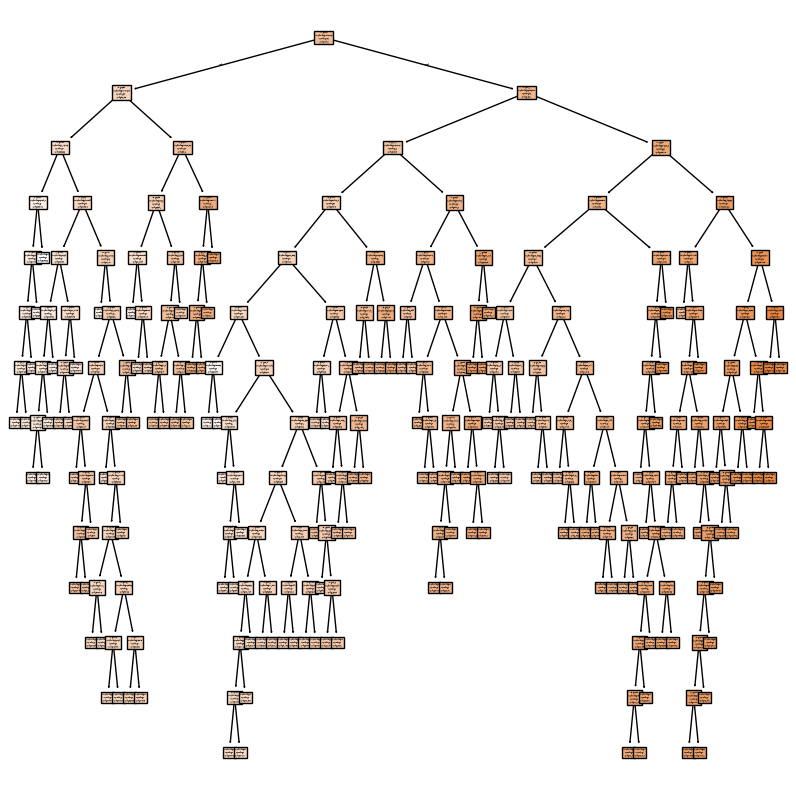

In [14]:
from sklearn import tree
plt.figure(figsize=(10,10))
tree.plot_tree(tree_reg,filled =True, feature_names =x.columns)

I am tring use diffrent para meter in desion tree with GridSearchcv :
class sklearn.tree.DecisionTreeRegressor(*, criterion='squared_error', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, ccp_alpha=0.0, monotonic_cst=None)[source]
 and gridSearchCV :
 class sklearn.model_selection.GridSearchCV(estimator, param_grid, *, scoring=None, n_jobs=None, refit=True, cv=None, verbose=0, pre_dispatch='2*n_jobs', error_score=nan, return_train_score=False)
 where estimeter : model (desiontree)


pretuning where you select parameter before train:
we took all param

In [15]:


tree_model = DecisionTreeRegressor(random_state=42)

hyper_params = {
    'max_depth': [None, 1, 2, 3, 5, 10],
    'criterion': ['squared_error', 'absolute_error'],
    'splitter': ['best', 'random']
}

reg1 = GridSearchCV(
    tree_model,
    hyper_params,
    scoring='neg_mean_squared_error',
    cv=5
)

reg1.fit(x_train, y_train)

print("Best hyperparameters for decision tree model:", reg1.best_params_)

Best hyperparameters for decision tree model: {'criterion': 'absolute_error', 'max_depth': 10, 'splitter': 'best'}


In [16]:
tree_reg_pred1 = reg1.predict(x_val)

In [17]:
tree_model = DecisionTreeRegressor(random_state=42)

# Find the best hyperparameter through GridSearch.
hyper_params = {'max_depth': (None, 1, 2, 3, 5, 10)}
reg = GridSearchCV(
    tree_model,
    hyper_params,
    scoring='neg_root_mean_squared_error',
    cv=5
)

reg.fit(x_train, y_train)

print("Best hyperparameter for desion tree model is:",reg.best_params_)

Best hyperparameter for desion tree model is: {'max_depth': None}


In [18]:
tree_reg_pred = reg.predict(x_val)

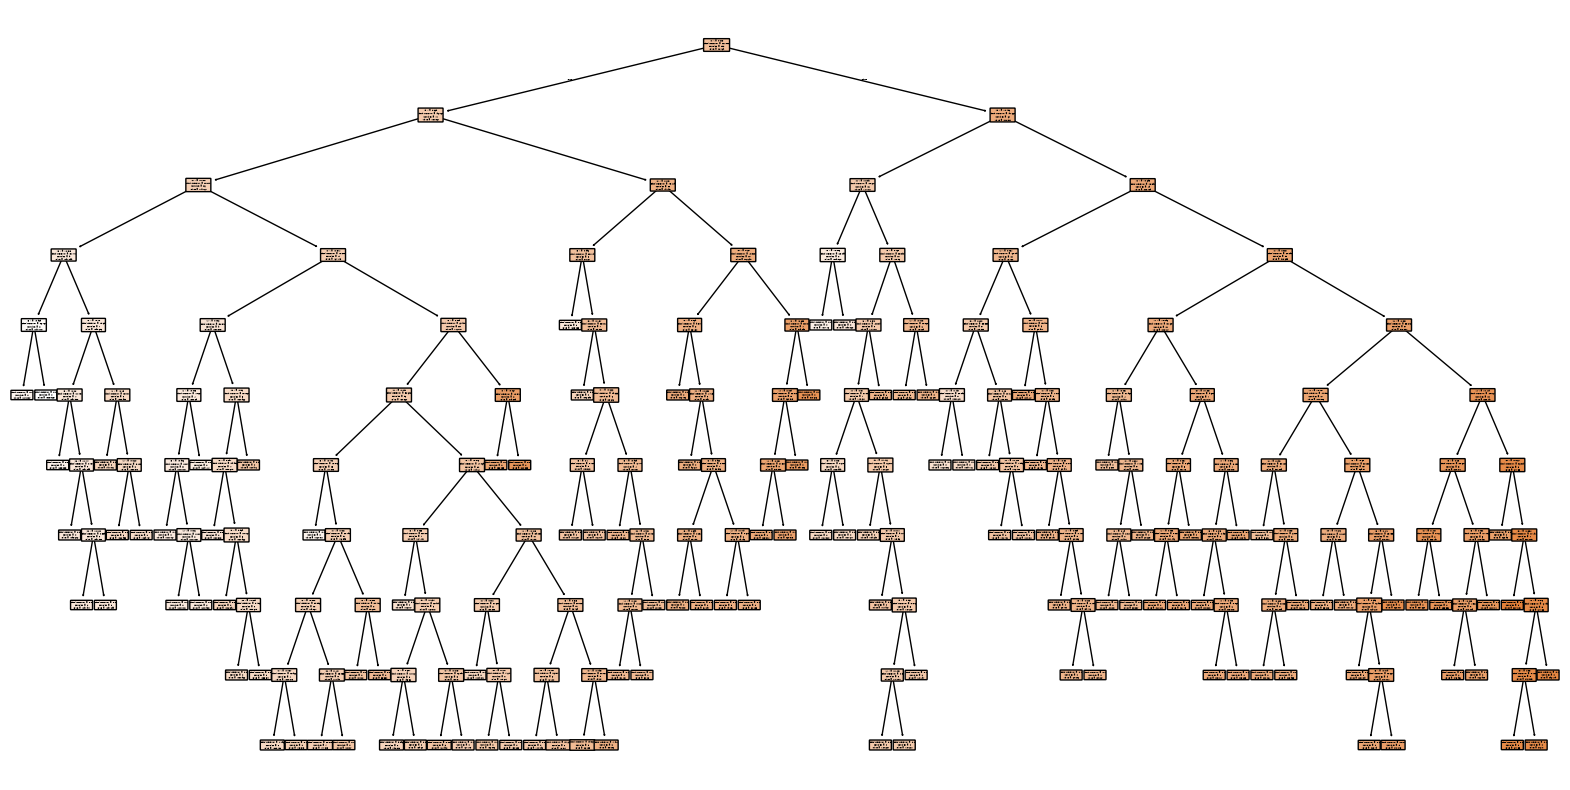

In [19]:
from sklearn import tree
import matplotlib.pyplot as plt

best_tree = reg1.best_estimator_

plt.figure(figsize=(20, 10))

tree.plot_tree(
    best_tree,
    filled=True,
    feature_names=x_train.columns,
    rounded=True
)

plt.show()

In [26]:
print(reg.best_params_)
pd.DataFrame(reg.cv_results_)

{'max_depth': None}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.008403,0.010267,0.002040,0.000725,None,{'max_depth': None},-85.372198,-87.317105,-108.826553,-99.897533,-115.017980,-99.286274,11.625314,1
1,0.001693,0.000775,0.001347,0.000687,1,{'max_depth': 1},-142.699335,-127.293588,-121.609649,-138.927047,-128.795876,-131.865099,7.781322,6
2,0.001252,0.000146,0.000842,0.000084,2,{'max_depth': 2},-132.879701,-116.251340,-113.785761,-127.318456,-107.387003,-119.524452,9.274402,5
3,0.001289,0.000295,0.000857,0.000114,3,{'max_depth': 3},-122.731829,-89.335367,-107.025455,-106.622713,-108.538314,-106.850736,10.601205,4
4,0.001601,0.000456,0.001027,0.000391,5,{'max_depth': 5},-94.067606,-89.305128,-105.266532,-95.576414,-113.702013,-99.583539,8.760776,2
5,0.001595,0.000343,0.001110,0.000173,10,{'max_depth': 10},-85.260013,-93.232499,-108.935520,-102.469020,-117.716456,-101.522702,11.413024,3


In [21]:
def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred))
    }

validation_results = pd.DataFrame({
    'Linear Regression': regression_metrics(y_val, linear_pred),
    'Decision Tree': regression_metrics(y_val, tree_reg_pred),
    'Decision Tree with parameter': regression_metrics(y_val, tree_reg_pred1)
}).T

validation_results

,MAE,RMSE
Linear Regression,2.760558,3.592301
Decision Tree,77.491086,99.359419
Decision Tree with parameter,61.469035,84.766535


In [20]:
def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred))
    }

validation_results = pd.DataFrame({
    'Linear Regression': regression_metrics(y_val, linear_pred),
    'Decision Tree': regression_metrics(y_val, tree_reg_pred)
}).T

validation_results

,MAE,RMSE
Linear Regression,2.760558,3.592301
Decision Tree,77.491086,99.359419


In [30]:
#train whole model on train+val data and test on test data
# Now we retrain our chosen model on the train + validation data.
lin_reg_final = LinearRegression().fit(x_train_val, y_train_val)
pred_test = lin_reg_final.predict(x_test)

In [55]:
test_results = pd.Series(
    regression_metrics(y_test, pred_test),
    name='Test set'
)
test_results

MAE     2.685240
RMSE    3.371549
Name: Test set, dtype: float64